In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/uniquetech/classroom-air-quality/unique_tech_classroom_air_quality.csv


In [2]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score

# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("/kaggle/input/datasets/uniquetech/classroom-air-quality/unique_tech_classroom_air_quality.csv")

df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good


In [3]:
# =========================================
# 3. BASIC INFO
# =========================================
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
 10  air_quality_label        500 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 43.1+ KB


timestamp                  0
school_period              0
student_count_estimated    0
co2_ppm                    0
pm25_ugm3                  0
temperature_c              0
humidity_pct               0
robot_x_pos                0
robot_y_pos                0
ventilation_decision       0
air_quality_label          0
dtype: int64

In [4]:
# =========================================
# 4. DATA CLEANING
# =========================================
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute

# Encode categorical
le = LabelEncoder()
df['air_quality_label_encoded'] = le.fit_transform(df['air_quality_label'])
df['ventilation_encoded'] = le.fit_transform(df['ventilation_decision'])

df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label,hour,minute,air_quality_label_encoded,ventilation_encoded
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good,8,0,0,0
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good,8,1,0,0
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good,8,3,0,0
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good,8,5,0,0
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good,8,6,0,0


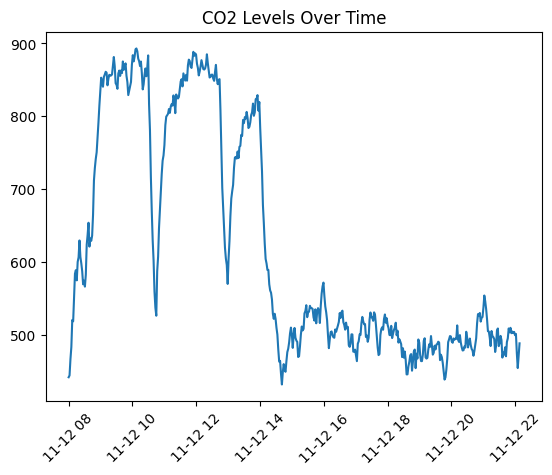

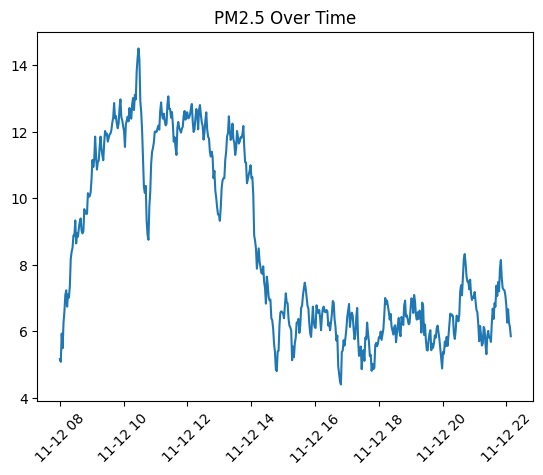

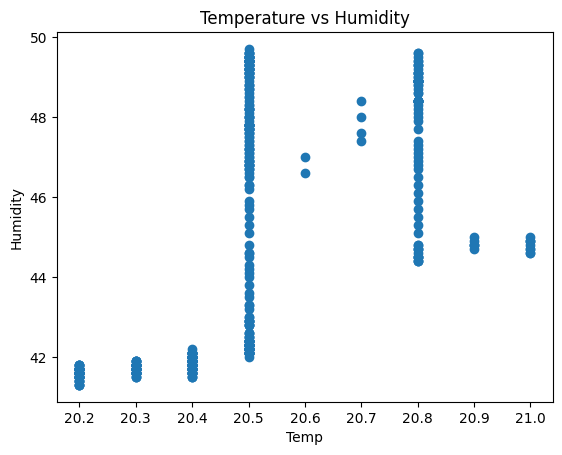

In [5]:
# =========================================
# 5. EDA - VISUALIZATION
# =========================================

# CO2 Trend
plt.figure()
plt.plot(df['timestamp'], df['co2_ppm'])
plt.title("CO2 Levels Over Time")
plt.xticks(rotation=45)
plt.show()

# PM2.5 Trend
plt.figure()
plt.plot(df['timestamp'], df['pm25_ugm3'])
plt.title("PM2.5 Over Time")
plt.xticks(rotation=45)
plt.show()

# Temperature vs Humidity
plt.figure()
plt.scatter(df['temperature_c'], df['humidity_pct'])
plt.title("Temperature vs Humidity")
plt.xlabel("Temp")
plt.ylabel("Humidity")
plt.show()

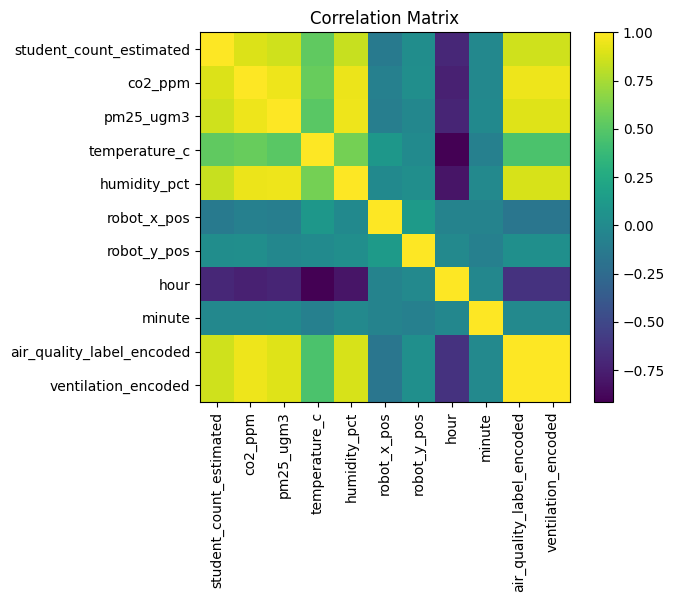

In [6]:
# =========================================
# 6. CORRELATION
# =========================================
corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [7]:
# =========================================
# 7. FEATURE SELECTION
# =========================================
features = [
    'student_count_estimated',
    'co2_ppm',
    'pm25_ugm3',
    'temperature_c',
    'humidity_pct',
    'hour'
]

X = df[features]
y_class = df['air_quality_label_encoded']
y_reg = df['co2_ppm']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# =========================================
# 8. CLASSIFICATION MODEL
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        33

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [9]:
# =========================================
# 9. REGRESSION MODEL (CO2 PREDICTION)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 2.344414380000199
R2: 0.9999080528377979


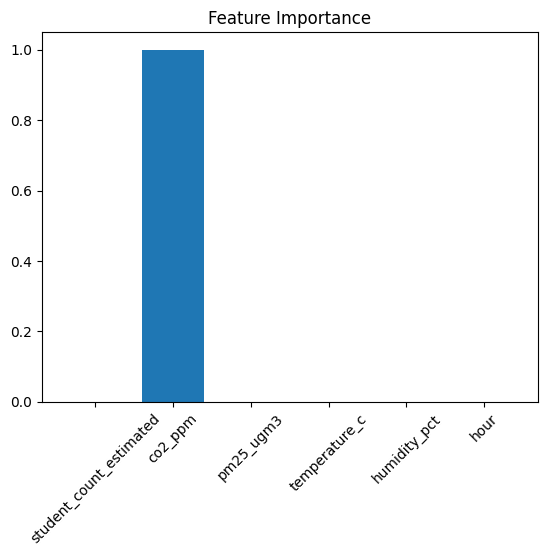

In [10]:
# =========================================
# 10. FEATURE IMPORTANCE
# =========================================
importance = reg.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [11]:
# =========================================
# 11. INSIGHTS
# =========================================
print("Average CO2:", df['co2_ppm'].mean())
print("Max CO2:", df['co2_ppm'].max())
print("Min CO2:", df['co2_ppm'].min())

print("\nAir Quality Distribution:")
print(df['air_quality_label'].value_counts())

Average CO2: 619.2663999999999
Max CO2: 893.0
Min CO2: 432.2

Air Quality Distribution:
air_quality_label
Good        335
Moderate    165
Name: count, dtype: int64


In [12]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2026-05-02 09:13:54.839482: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777713235.057710      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777713235.123187      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777713235.661096      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777713235.661152      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777713235.661155      16 computation_placer.cc:177] computation placer alr

In [13]:
# Select features
features = [
    'student_count_estimated',
    'co2_ppm',
    'pm25_ugm3',
    'temperature_c',
    'humidity_pct'
]

data = df[features].values

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][1])  # predict CO2
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled)

print(X.shape, y.shape)

(490, 10, 5) (490,)


In [14]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [15]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

2026-05-02 09:14:21.119002: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.2152 - mae: 0.3327 - val_loss: 0.0018 - val_mae: 0.0328
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0235 - mae: 0.1150 - val_loss: 0.0014 - val_mae: 0.0305
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - mae: 0.0779 - val_loss: 0.0019 - val_mae: 0.0349
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0136 - mae: 0.0830 - val_loss: 0.0016 - val_mae: 0.0324
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0142 - mae: 0.0852 - val_loss: 0.0018 - val_mae: 0.0339
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0106 - mae: 0.0763 - val_loss: 0.0017 - val_mae: 0.0332
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0098 - mae: 0.0743 - val_loss: 0.0023 - val_mae: 0.0390
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084 - mae: 0.0683 - val_loss: 0.0013 - val_mae: 0.0303
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.010

In [17]:
loss, mae = model.evaluate(X_test, y_test)
print("MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - mae: 0.0268    
MAE: 0.027799805626273155


In [18]:
y_pred = model.predict(X_test)

# Convert back to real values
y_pred_rescaled = scaler.inverse_transform(
    np.concatenate([X_test[:, -1, :-1], y_pred], axis=1)
)[:, -1]

y_test_rescaled = scaler.inverse_transform(
    np.concatenate([X_test[:, -1, :-1], y_test.reshape(-1,1)], axis=1)
)[:, -1]


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step


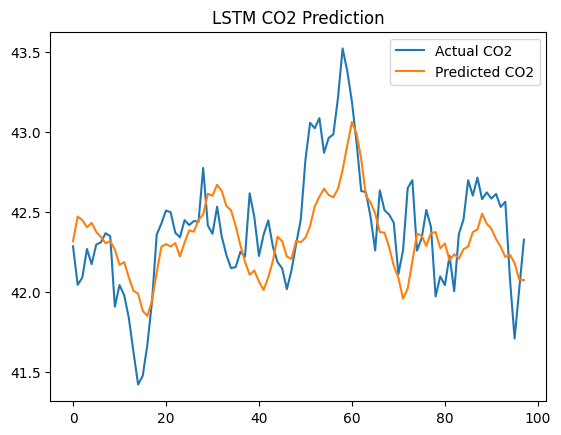

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_rescaled, label="Actual CO2")
plt.plot(y_pred_rescaled, label="Predicted CO2")
plt.legend()
plt.title("LSTM CO2 Prediction")
plt.show()
